In [4]:
import  numpy as np
import sympy as sp
from control import matlab as mt
import scipy as scp
import matplotlib.pyplot as plt
import scienceplots 

plt.style.use(["science","no-latex"])


In [95]:
from sympy.abc  import f
n=sp.symbols("n",integer=True)
t=sp.symbols("t",real=True)

Example 1:

$T=2$

$\omega=\pi$

$0\let$


In [96]:
T=2
w=2*sp.pi/T
x=sp.exp(-2*t)

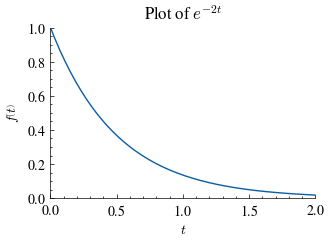

In [97]:
sp.plot(x,ylim=[0,1],xlim=[0,2],title="Plot of $e^{-2t}$")
plt.show()

$C_n=\frac{1}{T}\int_{0}^{T}{x(t)e^{-jn\omega_o t} dt}$

In [100]:
C_n=(1/T)*sp.integrate((x*sp.exp(-sp.I*n*w*t)),(t,0,2))
sp.simplify(C_n)

0.5*I*(1 - exp(4))*exp(-4)/(1.0*pi*n - 2.0*I)

In [99]:
y=sp.lambdify(n,C_n,modules=["numpy","scipy"])

In [80]:
n_values=np.arange(-20,20,1)

In [81]:
y_n=y(n_values)

In [82]:
y_n
np.abs(y_n).shape

(40,)

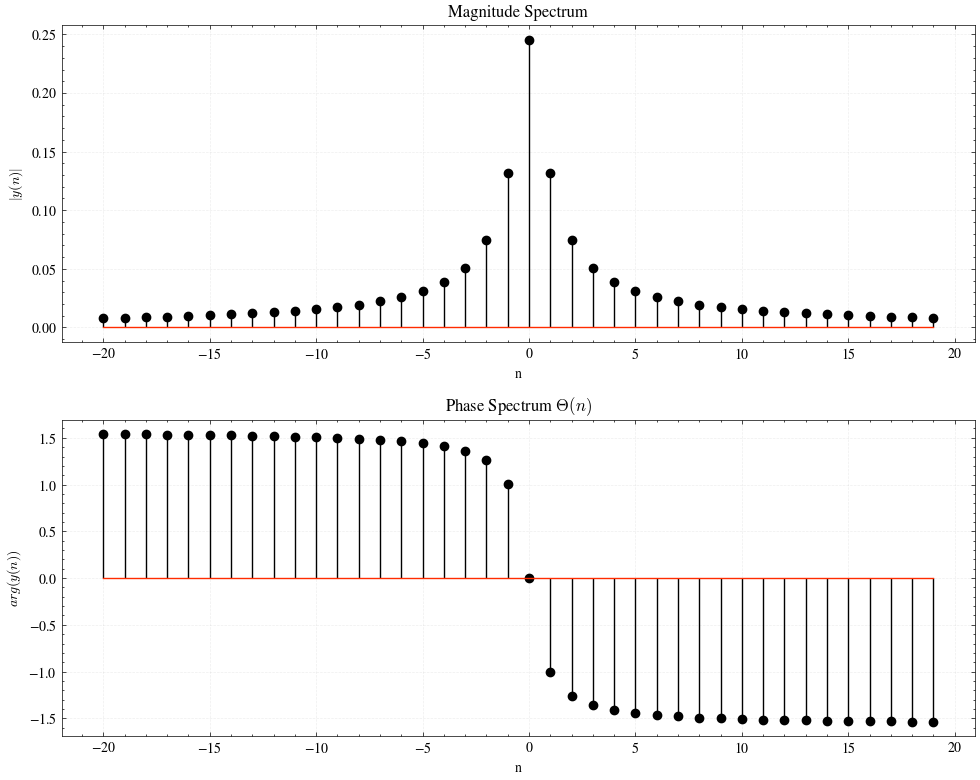

In [108]:
 #magnitude and phase plot

fig,ax=plt.subplots(ncols=1,nrows=2,figsize=(10,8))
ax[0].stem(n_values,np.abs(y_n),"black")
ax[0].set_title("Magnitude Spectrum")
ax[0].set_ylabel("$|y(n)|$")
ax[1].stem(n_values,np.atan(np.imag(y_n)/np.real(y_n)),"black")
ax[1].set_title("Phase Spectrum $\Theta(n)$")
ax[1].set_ylabel("$arg(y(n))$")

for x in ax:
    x.set_xlabel("n")
    x.grid(True,alpha=0.2,linestyle="--")
plt.tight_layout()
plt.show()

In [153]:

T=4
w=sp.pi/2
x=3*sp.cos(sp.pi*t/2+sp.pi/4)
x

3*cos(pi*t/2 + pi/4)

In [154]:
C_n=(1/T)*sp.integrate((x*sp.exp(-sp.I*n*w*t)),(t,0,2*sp.pi))
sp.simplify(C_n)

Piecewise((1.0*(-0.375*sqrt(2) - 0.75*(-1)**(3/4)*pi**2 + 0.75*exp(I*pi**2)*sin(pi*(1/4 + pi)))/pi, Eq(n, -1)), (-0.375*sqrt(2)/pi + 0.75*exp(-I*pi**2)*sin(pi/4 + pi**2)/pi + 0.75*pi*exp(I*pi/4), Eq(n, 1)), ((1.5*I*n*cos(pi*(1/4 + pi)) + 0.75*sqrt(2)*(-I*n + 1)*exp(I*pi**2*n) - 1.5*sin(pi*(1/4 + pi)))*exp(-I*pi**2*n)/(pi*(n**2 - 1)), True))

In [155]:
   C_n.subs(n,1)

-0.375*sqrt(2)/pi + 0.75*pi*exp(-I*pi**2)*cos(pi/4 + pi**2) + 0.75*exp(-I*pi**2)*sin(pi/4 + pi**2)/pi + 0.75*I*pi*exp(-I*pi**2)*sin(pi/4 + pi**2)

In [156]:
sp.simplify(C_n.subs(n,1))

(0.75*sin(pi*(1/4 + pi)) + 0.75*pi**2*exp(I*pi*(1/4 + pi)) - 0.375*sqrt(2)*exp(I*pi**2))*exp(-I*pi**2)/pi

In [164]:
y=sp.lambdify(n,C_n,modules=["numpy","scipy"])

In [163]:
np.abs(1.5*np.exp(-1j*np.pi/4))

np.float64(1.5000000000000002)

Input Energy = 0.25050033281692474
Output Energy = 0.22653050829901764
Ratio = 0.9043122049046332


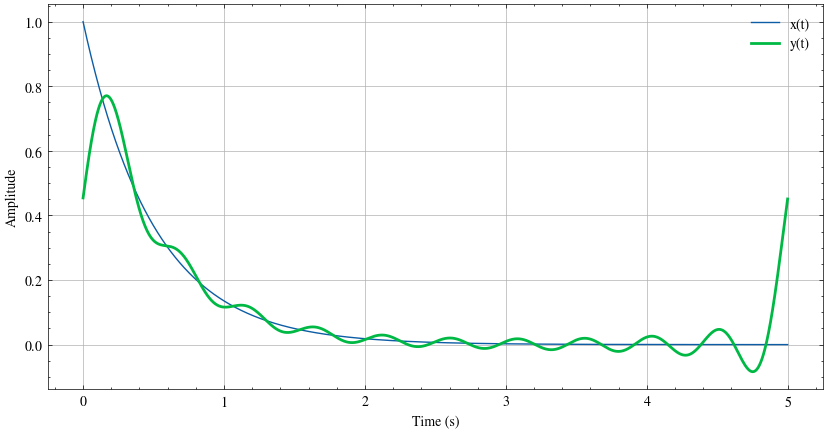

In [167]:
import numpy as np
import matplotlib.pyplot as plt

Fs = 1000
dt = 1/Fs
t = np.arange(0,5,dt)

# signal
x = np.exp(-2*t)

# FFT
X = np.fft.fft(x)
f = np.fft.fftfreq(len(x), dt)

# cutoff from analytical solution
fc = 2.01

# Ideal LPF
H = np.abs(f) <= fc

Y = X * H

# IFFT
y = np.real(np.fft.ifft(Y))

# Energies
Ex = np.sum(np.abs(x)**2)*dt
Ey = np.sum(np.abs(y)**2)*dt

print("Input Energy =", Ex)
print("Output Energy =", Ey)
print("Ratio =", Ey/Ex)

# plots
plt.figure(figsize=(10,5))
plt.plot(t,x,label='x(t)')
plt.plot(t,y,label='y(t)',linewidth=2)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid()
plt.legend()
plt.show()